In [1]:
import os
os.chdir("..")
print(os.getcwd())

D:\repositories\PyFlowSolver


In [2]:
%run .\pyflowsolver\volumeManager.py
%run .\pyflowsolver\sparseArray.py
%run .\pyflowsolver\fastLaplacian.py
%run .\pyflowsolver\darcySolver.py

In [3]:
import porespy as ps

In [4]:
PORE = 1
INLET = 2
OUTLET = 3

In [5]:
'''
vol = ps.generators.blobs(shape=(20, 20, 20), blobiness=0.4, porosity=0.55).astype(np.uint8)
vol[1, 5:25, 5:10] = INLET
vol[2, 5:25, 13:19] = INLET
vol[17, 5:25, 3:19] = OUTLET
'''
vol = np.ones((5,5,5), dtype=np.uint8)
vol[:,0,:] = 2
vol[:, -1, :] = 3
vol[2, 2, 2] = 0

In [6]:
import numpy as np
import scipy as sc
from numba import njit

In [7]:
lab, n_lab = sc.ndimage.label(vol)

In [8]:
@njit
def filter_connected_volume(volume, labels):
    w, h, d = volume.shape
    inlet_set = set()
    outlet_set = set()
    for i in range(w):
        for j in range(h):
            for k in range(d):
                if volume[i, j, k] == INLET:
                    label = labels[i, j, k]
                    if label != 0:
                        inlet_set.add(label)
                elif volume[i, j, k] == OUTLET:
                    label = labels[i, j, k]
                    if label != 0:
                        outlet_set.add(label)
    connected_labels = inlet_set.intersection(outlet_set)
    for i in range(w):
        for j in range(h):
            for k in range(d):
                if labels[i, j, k] not in connected_labels:
                    volume[i,j,k] = 0

filter_connected_volume(vol, lab)


In [9]:
print(vol)

[[[2 2 2 2 2]
  [1 1 1 1 1]
  [1 1 1 1 1]
  [1 1 1 1 1]
  [3 3 3 3 3]]

 [[2 2 2 2 2]
  [1 1 1 1 1]
  [1 1 1 1 1]
  [1 1 1 1 1]
  [3 3 3 3 3]]

 [[2 2 2 2 2]
  [1 1 1 1 1]
  [1 1 0 1 1]
  [1 1 1 1 1]
  [3 3 3 3 3]]

 [[2 2 2 2 2]
  [1 1 1 1 1]
  [1 1 1 1 1]
  [1 1 1 1 1]
  [3 3 3 3 3]]

 [[2 2 2 2 2]
  [1 1 1 1 1]
  [1 1 1 1 1]
  [1 1 1 1 1]
  [3 3 3 3 3]]]


In [10]:
con_vol = (vol>=1)*100 #porosity map ndarray unit8 0..100

In [11]:
print(con_vol)

[[[100 100 100 100 100]
  [100 100 100 100 100]
  [100 100 100 100 100]
  [100 100 100 100 100]
  [100 100 100 100 100]]

 [[100 100 100 100 100]
  [100 100 100 100 100]
  [100 100 100 100 100]
  [100 100 100 100 100]
  [100 100 100 100 100]]

 [[100 100 100 100 100]
  [100 100 100 100 100]
  [100 100   0 100 100]
  [100 100 100 100 100]
  [100 100 100 100 100]]

 [[100 100 100 100 100]
  [100 100 100 100 100]
  [100 100 100 100 100]
  [100 100 100 100 100]
  [100 100 100 100 100]]

 [[100 100 100 100 100]
  [100 100 100 100 100]
  [100 100 100 100 100]
  [100 100 100 100 100]
  [100 100 100 100 100]]]


In [12]:
con_vol = fast_laplacian_volume_generator(
    con_vol, 
    (1.2, 1.2, 1.2), 
    )

In [13]:
volume_manager = VolumeManager(con_vol, boundary_volume=vol)

In [14]:
sparse_array, condensed_b = volume_manager.get_sparse_system_jit()

In [15]:
con_vol

array([[[0.36     , 0.36     , 0.36     , 0.36     , 0.36     ],
        [0.36     , 0.36     , 0.36     , 0.36     , 0.36     ],
        [0.36     , 0.36     , 0.36     , 0.36     , 0.36     ],
        [0.36     , 0.36     , 0.36     , 0.36     , 0.36     ],
        [0.36     , 0.36     , 0.36     , 0.36     , 0.36     ]],

       [[0.36     , 0.36     , 0.36     , 0.36     , 0.36     ],
        [3.2400002, 2.1858466, 1.2035325, 2.1858466, 3.2400002],
        [3.2400002, 1.2035325, 0.36     , 1.2035325, 3.2400002],
        [3.2400002, 2.1858466, 1.2035325, 2.1858466, 3.2400002],
        [0.36     , 0.36     , 0.36     , 0.36     , 0.36     ]],

       [[0.36     , 0.36     , 0.36     , 0.36     , 0.36     ],
        [3.2400002, 1.2035325, 0.36     , 1.2035325, 3.2400002],
        [3.2400002, 0.36     , 0.       , 0.36     , 3.2400002],
        [3.2400002, 1.2035325, 0.36     , 1.2035325, 3.2400002],
        [0.36     , 0.36     , 0.36     , 0.36     , 0.36     ]],

       [[0.36     ,

In [16]:
solver = DarcySolver()
solver.set_linear_system(sparse_array, condensed_b)
solver.generate_preconditioner(preconditioner="inverse_diagonal")
solution = solver.solve_cg()
raveled_solution = volume_manager.ravel_sparse_solution(solution[0])

In [17]:
print(condensed_b)
print(sparse_array["val"])
print(sparse_array["col_idx"])
print(sparse_array["row_ptr"])
print(solution)

[-0.72000003 -0.72000003 -0.72000003 -0.72000003 -0.72000003  0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.         -6.4800005  -4.37169313 -2.40706491
 -4.37169313 -6.4800005   0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
 -6.4800005  -2.40706491 -0.72000003 -2.40706491 -6.4800005   0.
  0.          0.          0.          0.          0.          0.
  0.          0.         -6.4800005  -4.37169313 -2.40706491 -4.37169313
 -6.4800005   0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.         -0.72000003
 -0.72000003 -0.72000003 -0.72000003 -0.72000003  0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.        ]
[  0.648        0.36000001   0.36000001  -2.08800006   0.61818713
   0.36000001   0.36000001   0.36000001  -2.4181872    0.55422157
   0.36000001   0.36000001   0.3600000

In [18]:
volume_manager.volume

array([[[0.36     , 0.36     , 0.36     , 0.36     , 0.36     ],
        [0.36     , 0.36     , 0.36     , 0.36     , 0.36     ],
        [0.36     , 0.36     , 0.36     , 0.36     , 0.36     ],
        [0.36     , 0.36     , 0.36     , 0.36     , 0.36     ],
        [0.36     , 0.36     , 0.36     , 0.36     , 0.36     ]],

       [[0.36     , 0.36     , 0.36     , 0.36     , 0.36     ],
        [3.2400002, 2.1858466, 1.2035325, 2.1858466, 3.2400002],
        [3.2400002, 1.2035325, 0.36     , 1.2035325, 3.2400002],
        [3.2400002, 2.1858466, 1.2035325, 2.1858466, 3.2400002],
        [0.36     , 0.36     , 0.36     , 0.36     , 0.36     ]],

       [[0.36     , 0.36     , 0.36     , 0.36     , 0.36     ],
        [3.2400002, 1.2035325, 0.36     , 1.2035325, 3.2400002],
        [3.2400002, 0.36     , 0.       , 0.36     , 3.2400002],
        [3.2400002, 1.2035325, 0.36     , 1.2035325, 3.2400002],
        [0.36     , 0.36     , 0.36     , 0.36     , 0.36     ]],

       [[0.36     ,

In [19]:
print(raveled_solution)

[[[1.         1.         1.         1.         1.        ]
  [0.8372104  0.844139   0.8485811  0.844139   0.8372104 ]
  [0.5        0.5        0.49999994 0.5        0.5       ]
  [0.16278957 0.15586102 0.15141907 0.15586102 0.16278957]
  [0.         0.         0.         0.         0.        ]]

 [[1.         1.         1.         1.         1.        ]
  [0.83982307 0.8644649  0.8840647  0.8644649  0.83982307]
  [0.5        0.5        0.49999997 0.5        0.5       ]
  [0.16017692 0.13553515 0.11593531 0.13553515 0.16017692]
  [0.         0.         0.         0.         0.        ]]

 [[1.         1.         1.         1.         1.        ]
  [0.8399606  0.8771704  0.90988505 0.8771704  0.8399606 ]
  [0.5        0.5        0.         0.5        0.5       ]
  [0.16003945 0.1228296  0.0901149  0.1228296  0.16003945]
  [0.         0.         0.         0.         0.        ]]

 [[1.         1.         1.         1.         1.        ]
  [0.83982307 0.8644649  0.8840647  0.8644649  0.8

In [20]:
import matplotlib.pyplot as plt

def plt_show(img, samples):
    num_slices = img.shape[2]
    fig, axs = plt.subplots(3, samples+1, figsize=(8, 8))
    
    for i in range(num_slices//samples):
        slice_2d = img[i*samples, :, :]
        axs[0,i].imshow(slice_2d, cmap='viridis', origin='upper')
        axs[0,i].set_title(f'Slice {i + 1}')
        axs[0,i].axis('off')  # Turn off axis for better visualization
    
        slice_2d = img[:, i*samples, :]
        axs[1,i].imshow(slice_2d, cmap='viridis', origin='upper')
        axs[1,i].set_title(f'Slice {i + 1 + 4}')
        axs[1,i].axis('off')  # Turn off axis for better visualization
    
        slice_2d = img[:, :, i*samples]
        axs[2,i].imshow(slice_2d, cmap='viridis', origin='upper')
        axs[2,i].set_title(f'Slice {i + 1 + 4}')
        axs[2,i].axis('off')  # Turn off axis for better visualization
    
    plt.tight_layout()
    plt.show()

0.0 1.0


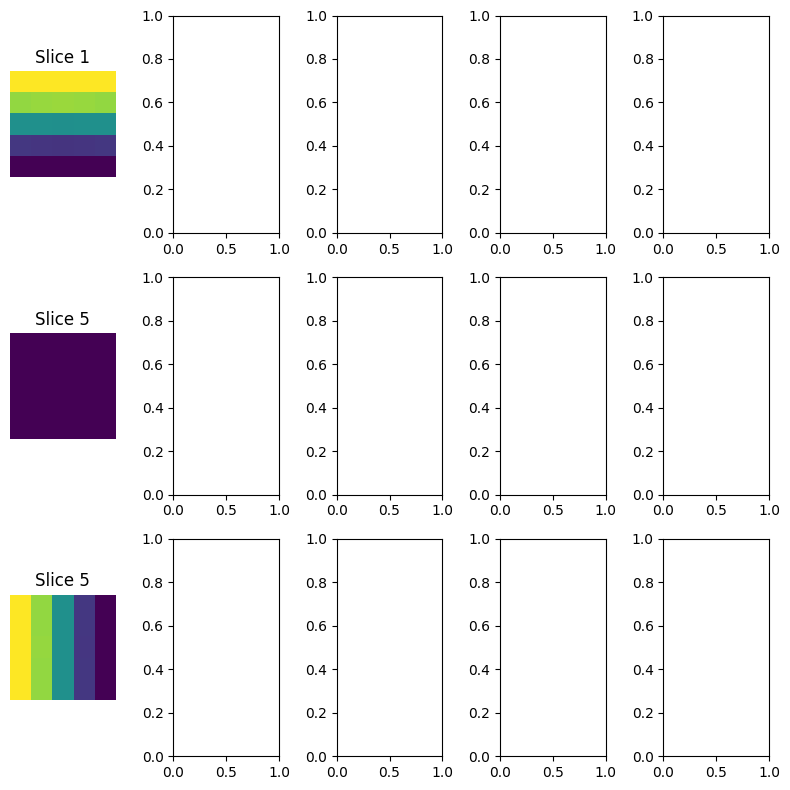

In [21]:
print(raveled_solution.min(), raveled_solution.max())
plt_show(raveled_solution, 4)

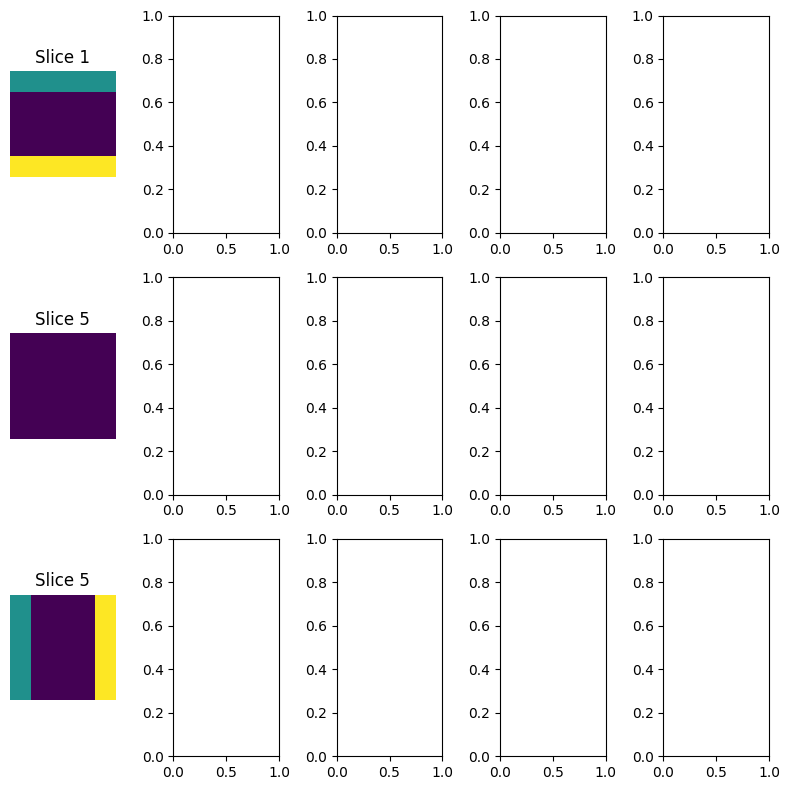

In [22]:
plt_show(vol, 4)

In [23]:
print(con_vol.min(), con_vol.max())
print(pressure_field[0, :, :].mean())
print(pressure_field[-1, :, :].mean())
print(pressure_field[:, 0, :].mean())
print(pressure_field[:, -1, :].mean())
print(pressure_field[:, :, 0].mean())
print(pressure_field[:, :, -1].mean())

0.0 3.2400002


NameError: name 'pressure_field' is not defined

In [ ]:
pressure_field = raveled_solution
x_pressure_gradient = np.zeros_like(pressure_field)
x_pressure_gradient[1:, :, :] -= x_pressure_gradient[:-1, :, :]
x_conductance = np.zeros_like(pressure_field)
x_conductance[1:, :, :] = 2/ (1/x_conductance[1:, :, :] + 1/x_conductance[:-1, :, :])
x_speed = x_pressure_gradient * x_conductance

In [ ]:
print(x_speed.min(), x_speed.max())
plt_show(x_speed, 4)

In [ ]:
ps.__dict__

In [ ]:
vol.max()

In [ ]:
vol